CVL_Assignment01 — Image Enhancement Using Linear Contrast Stretching


$$I_{out} = \frac{I_{in} - I_{min}}{I_{max} - I_{min}} \times 255$$

Using the **2nd and 98th percentiles** instead of the absolute min/max.

## 1. Imports

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

## 2. Linear Contrast Stretching Function

In [4]:
def linear_stretch(img_gray, low_pct=2, high_pct=98):
    
    min_val = np.percentile(img_gray, low_pct)
    max_val = np.percentile(img_gray, high_pct)
    stretched = np.clip(
        (img_gray.astype(float) - min_val) / (max_val - min_val) * 255,
        0, 255
    ).astype(np.uint8)
    return stretched


## 3. Load Images and Apply Enhancement

In [5]:
image_paths = image_paths = [
    r'dataset\image1.jpg',
    r'dataset\image2.jpg',
    r'dataset\image3.jpg',
    r'dataset\image4.jpg',
    r'dataset\image5.jpg',
]
image_labels =['image1', 'image2', 'image3', 'image4', 'image5']

originals = []
enhanced_imgs = []

for path, label in zip(image_paths, image_labels):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    enhanced = linear_stretch(gray)
    originals.append(gray)
    enhanced_imgs.append(enhanced)
    print(f'{label}: min={gray.min()}, max={gray.max()}, mean={gray.mean():.1f} '
          f'-> mean={enhanced.mean():.1f}')

image1: min=53, max=228, mean=87.0 -> mean=56.4
image2: min=41, max=237, mean=74.1 -> mean=55.5
image3: min=44, max=238, mean=84.8 -> mean=79.8
image4: min=51, max=248, mean=124.2 -> mean=116.4
image5: min=33, max=208, mean=87.0 -> mean=104.6


## 4. Visualization — Original vs Enhanced + Histograms

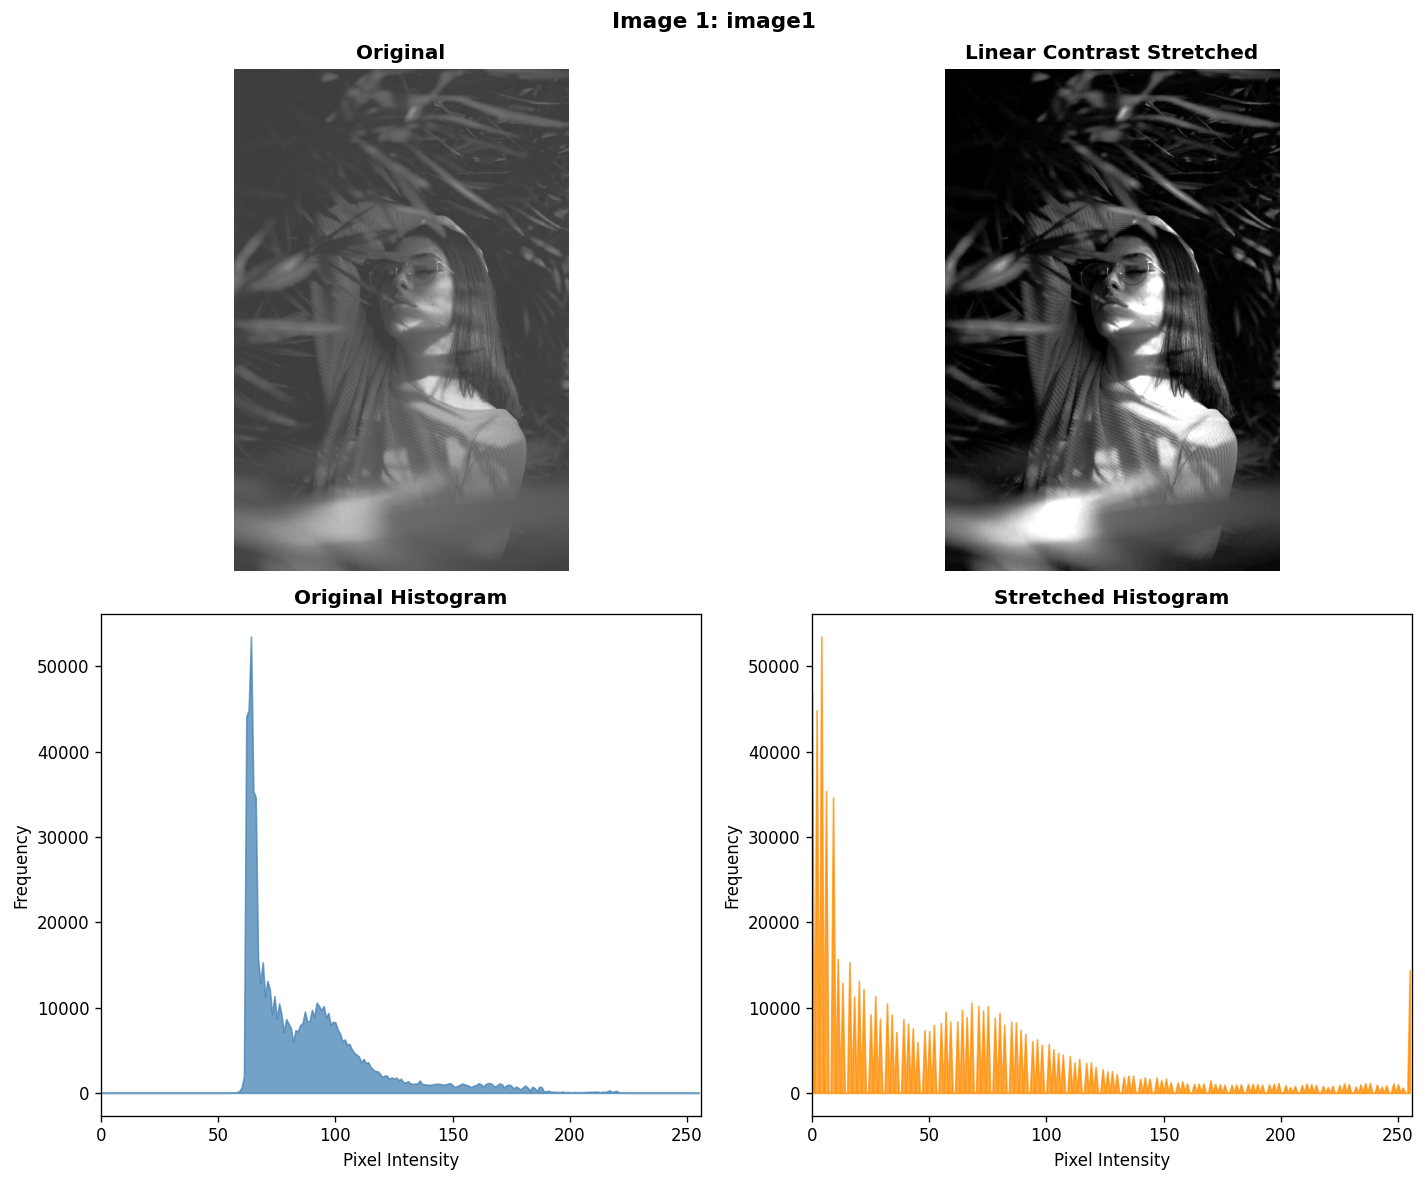

Image 1 saved.


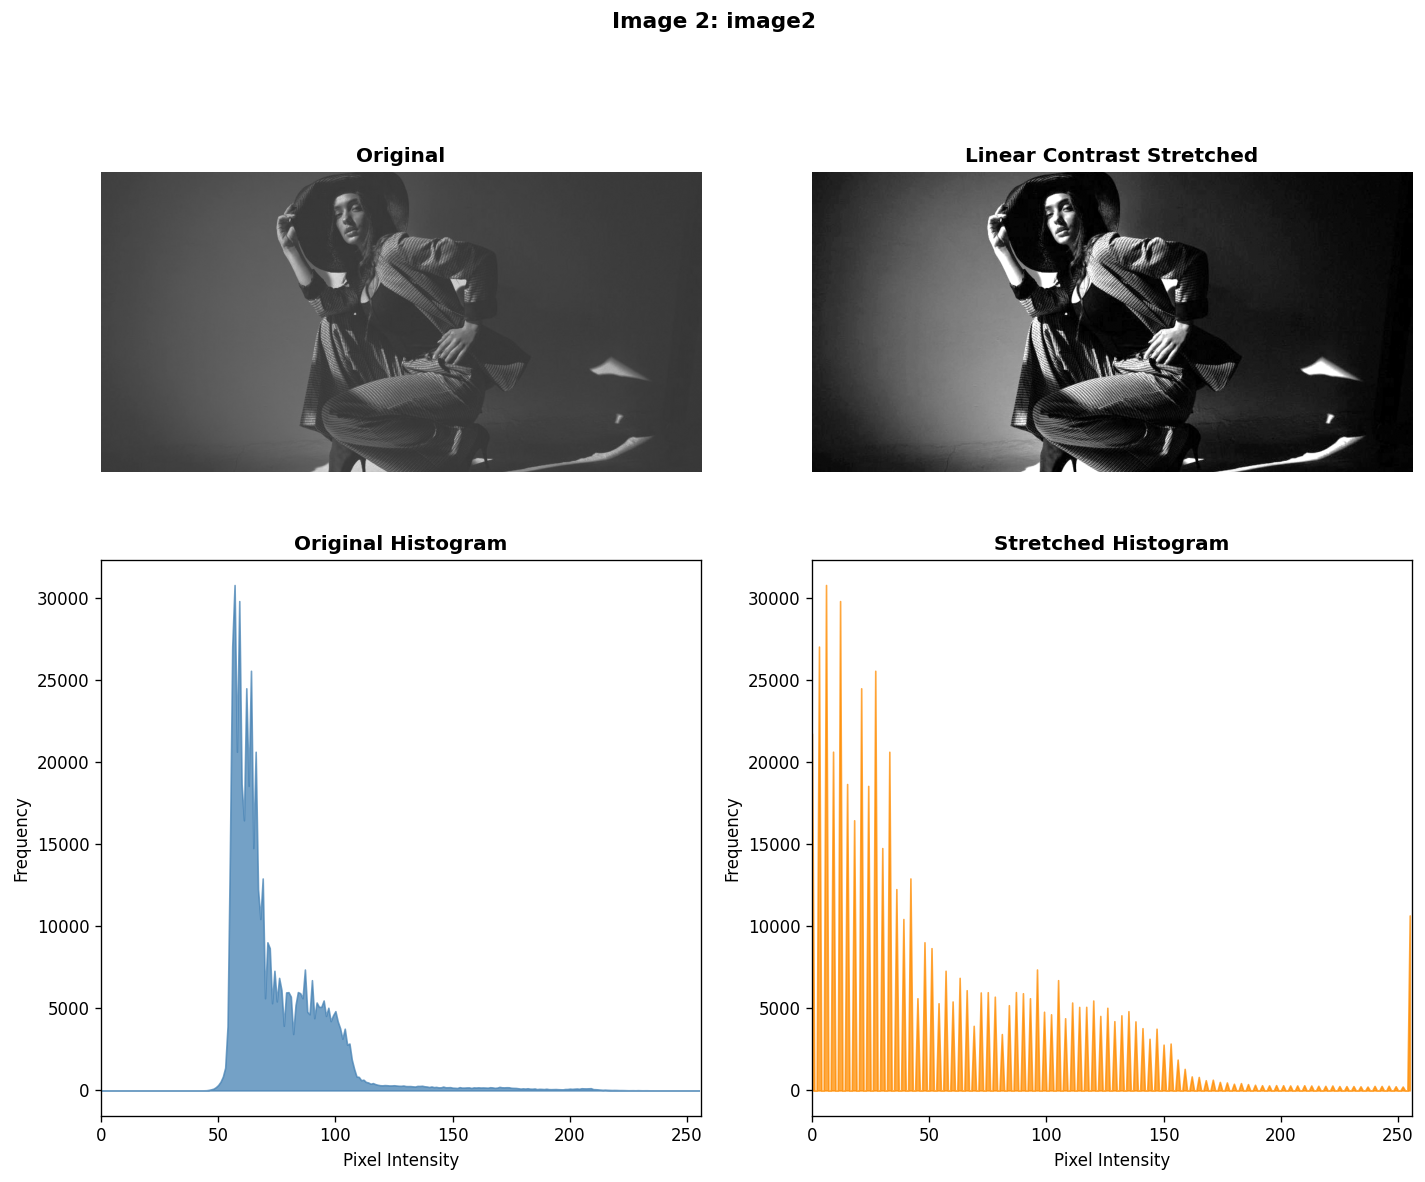

Image 2 saved.


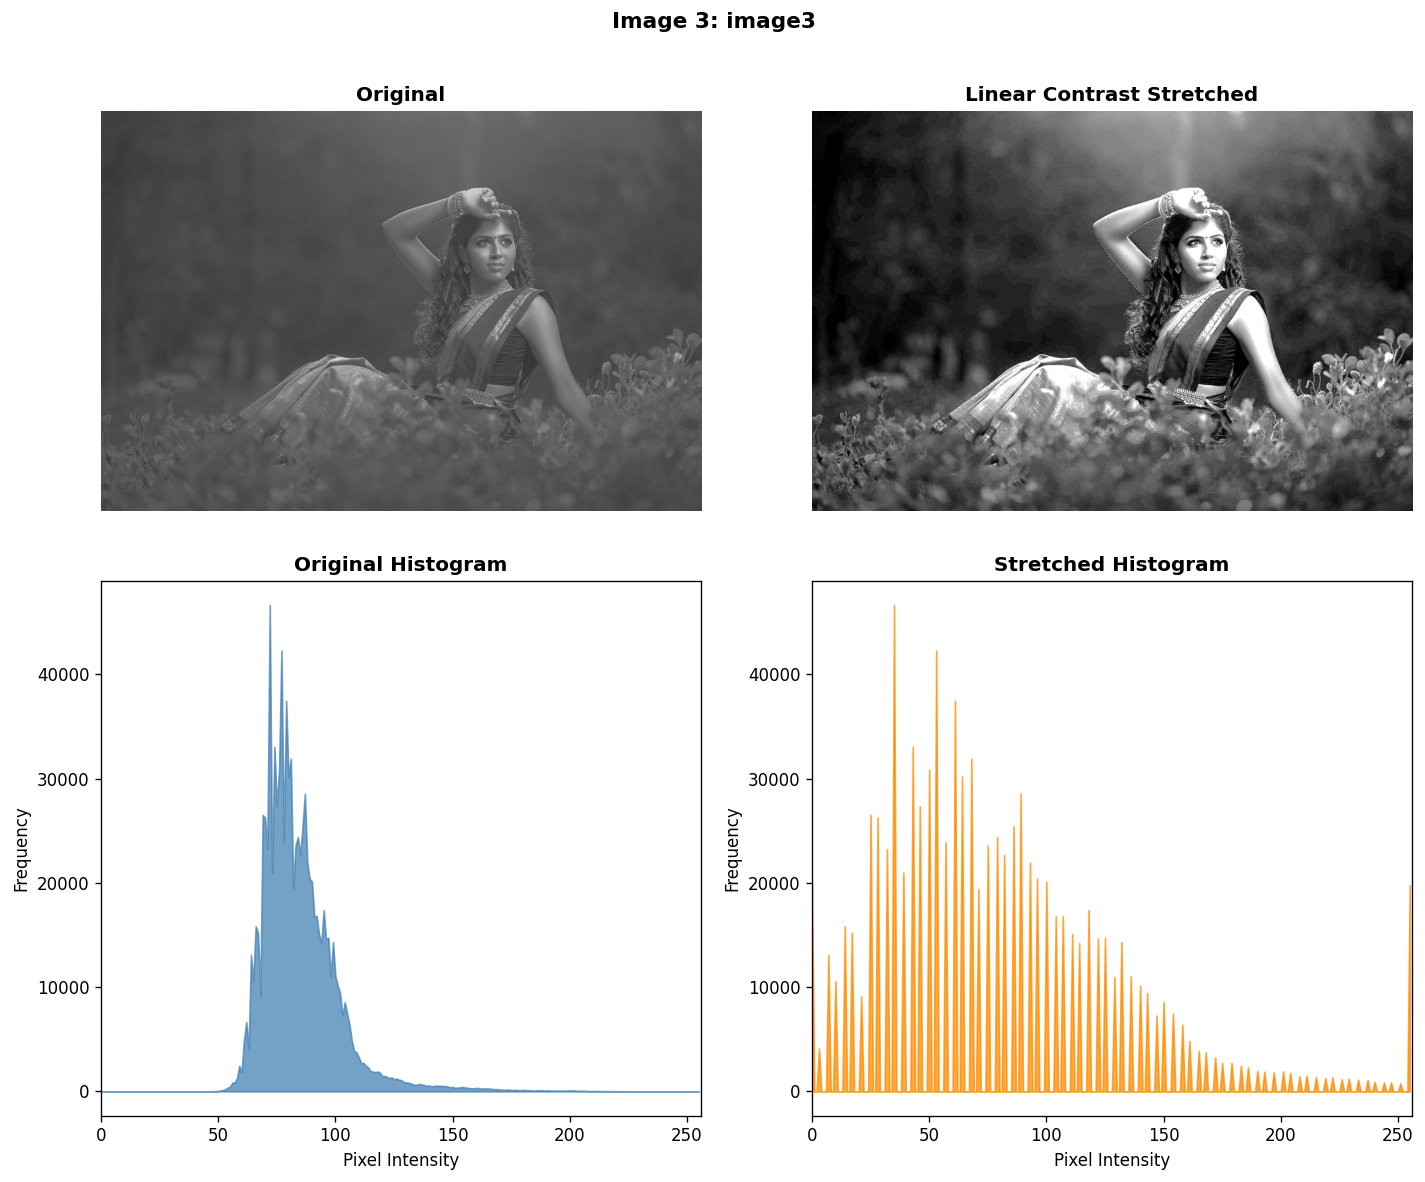

Image 3 saved.


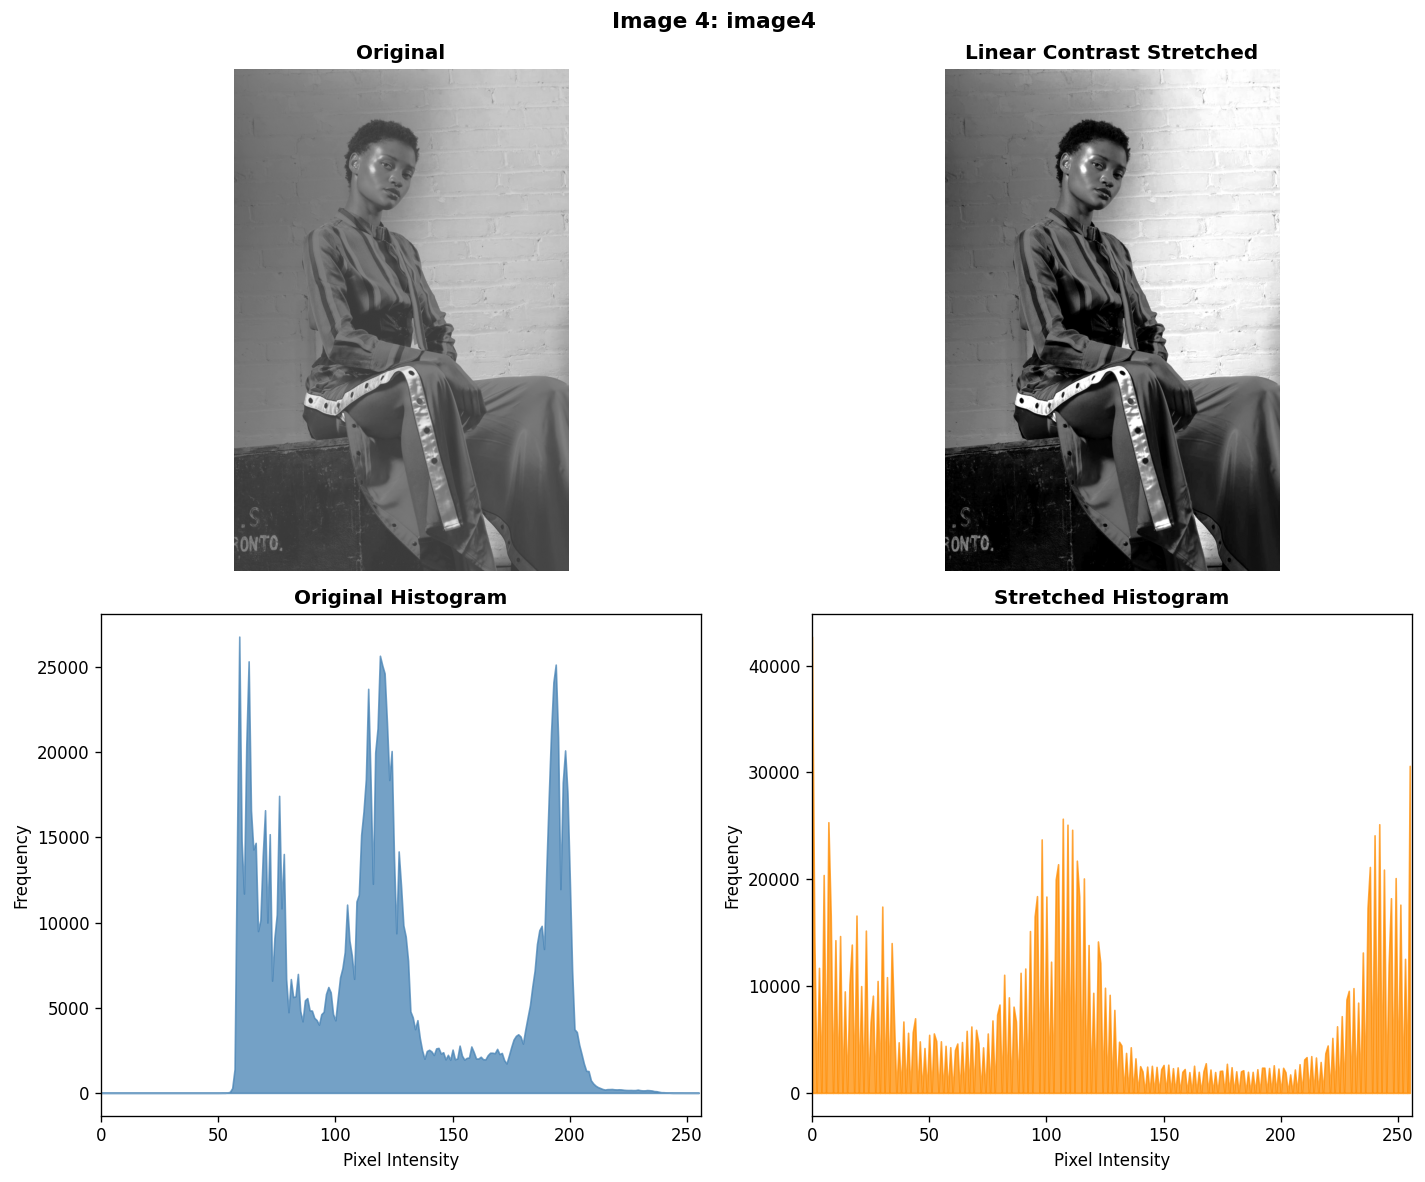

Image 4 saved.


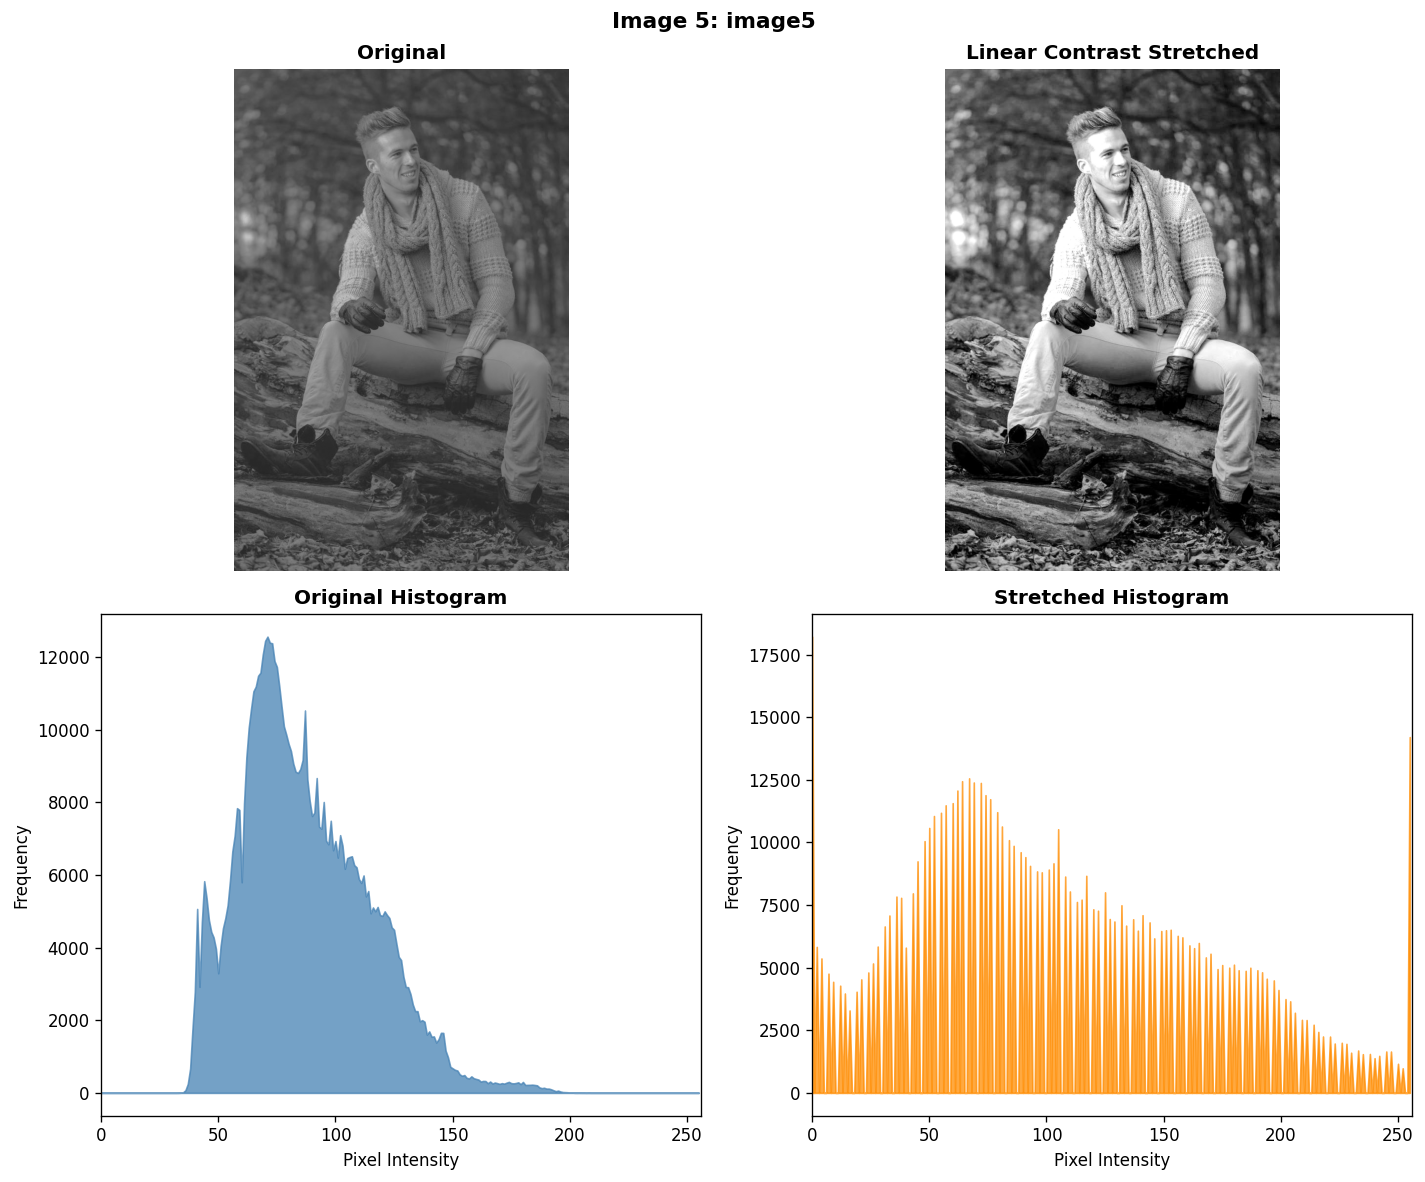

Image 5 saved.


In [6]:
for idx, (gray, enhanced, label) in enumerate(zip(originals, enhanced_imgs, image_labels), 1):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Image {idx}: {label}', fontsize=13, fontweight='bold')

    axes[0][0].imshow(gray, cmap='gray', vmin=0, vmax=255)
    axes[0][0].set_title('Original', fontweight='bold')
    axes[0][0].axis('off')

    axes[0][1].imshow(enhanced, cmap='gray', vmin=0, vmax=255)
    axes[0][1].set_title('Linear Contrast Stretched', fontweight='bold')
    axes[0][1].axis('off')

    for ax, im, t, color in zip(
        [axes[1][0], axes[1][1]],
        [gray, enhanced],
        ['Original Histogram', 'Stretched Histogram'],
        ['steelblue', 'darkorange']
    ):
        hist = cv2.calcHist([im], [0], None, [256], [0, 256])
        ax.fill_between(range(256), hist.flatten(), alpha=0.75, color=color)
        ax.set_title(t, fontweight='bold')
        ax.set_xlabel('Pixel Intensity')
        ax.set_ylabel('Frequency')
        ax.set_xlim([0, 256])

    plt.tight_layout()
    plt.savefig(f'img{idx}_linear_stretch.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Image {idx} saved.')


## 5. Quantitative Evaluation

In [ ]:
print(f'{'Image':<32} {'Orig Mean':>10} {'Orig Std':>9} {'Enh Mean':>10} {'Enh Std':>9}')
print('-' * 75)
for label, orig, enh in zip(image_labels, originals, enhanced_imgs):
    print(f'{label:<32} {orig.mean():>10.2f} {orig.std():>9.2f} '
          f'{enh.mean():>10.2f} {enh.std():>9.2f}')


Image                             Orig Mean  Orig Std   Enh Mean   Enh Std
---------------------------------------------------------------------------
image1                                87.04     27.93      56.42     61.67
image2                                74.12     21.51      55.51     55.73
image3                                84.79     16.88      79.84     53.07
image4                               124.21     46.81     116.39     83.58
image5                                86.96     27.39     104.57     63.38


## 6. Conclusion

Linear Contrast Stretching effectively enhances low-contrast images by mapping the meaningful intensity range to the full 8-bit spectrum.

- The **standard deviation (Std)** increases after stretching, confirming improved contrast.
- The **histograms** spread from a narrow cluster to a wider distribution across [0, 255].
- Using the **2nd–98th percentile** instead of absolute min/max prevents a few bright/dark outlier pixels from compressing the rest of the image.
- The technique is **fast, parameter-light**, and well-suited for portrait photography where global tonal balance is desired.